In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Pré-processamento e pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Avaliação de modelos
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    cross_val_predict,
    learning_curve,
    StratifiedKFold,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
import sys
import sklearn
import platform

print("Python:", sys.version)
print("Python (curto):", platform.python_version())
print("scikit-learn:", sklearn.__version__)


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Python (curto): 3.12.12
scikit-learn: 1.6.1


In [ ]:
dados = pd.read_csv('/content/df_w_geometric_features - features_selected.csv')

In [ ]:
dados.head()
dados_metrics = dados.iloc[:,3:7]
dados_metrics = dados_metrics.apply(lambda x: x.astype(str).str.replace(',', '.')).astype(float)
dados[['circularity', 'aspect_ratio', 'rectangularity','solidity',]] = dados_metrics[['circularity', 'aspect_ratio', 'rectangularity', 'solidity']]
dados = dados[dados['detected_mask_id']>=0]
#dados.info() Para verificar que os dados estão no seu tipo correto

In [ ]:
#Observando as classes presentes no dataset
dados['classification'].value_counts()

,count
classification,
0,210
1,110


In [ ]:
#Separação das variáveis explicativas e resposta
X,y= dados.iloc[:,3:7], dados['classification']

In [ ]:
# Definir a validação cruzada com estratificação e embaralhamento
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Lista para guardar os resultados
results = []

# Lista com modelos e seus nomes
modelos = [
    ("SVM", Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC())
    ])),

    ("KNN", Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors=5))
    ])),

    ("Árvore de Decisão", DecisionTreeClassifier(random_state=42))  # Não precisa padronizar
]

# Avaliar cada modelo com validação cruzada estratificada e embaralhada
for nome, modelo in modelos:
    scores = cross_validate(
        modelo, X, y,
        cv=cv,
        scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
        return_train_score=False
    )
    results.append({
        'Modelo': nome,
        'Acurácia': scores['test_accuracy'].mean(),
        'Precisão': scores['test_precision_weighted'].mean(),
        'Revocação': scores['test_recall_weighted'].mean(),
        'F1-Score': scores['test_f1_weighted'].mean()
    })

# Exibir resultados em formato de DataFrame 0.96
df_resultados = pd.DataFrame(results)
print(df_resultados)


              Modelo  Acurácia  Precisão  Revocação  F1-Score
0                SVM  0.959375  0.961004   0.959375  0.958683
1                KNN  0.940625  0.942798   0.940625  0.939763
2  Árvore de Decisão  0.971875  0.973179   0.971875  0.971615


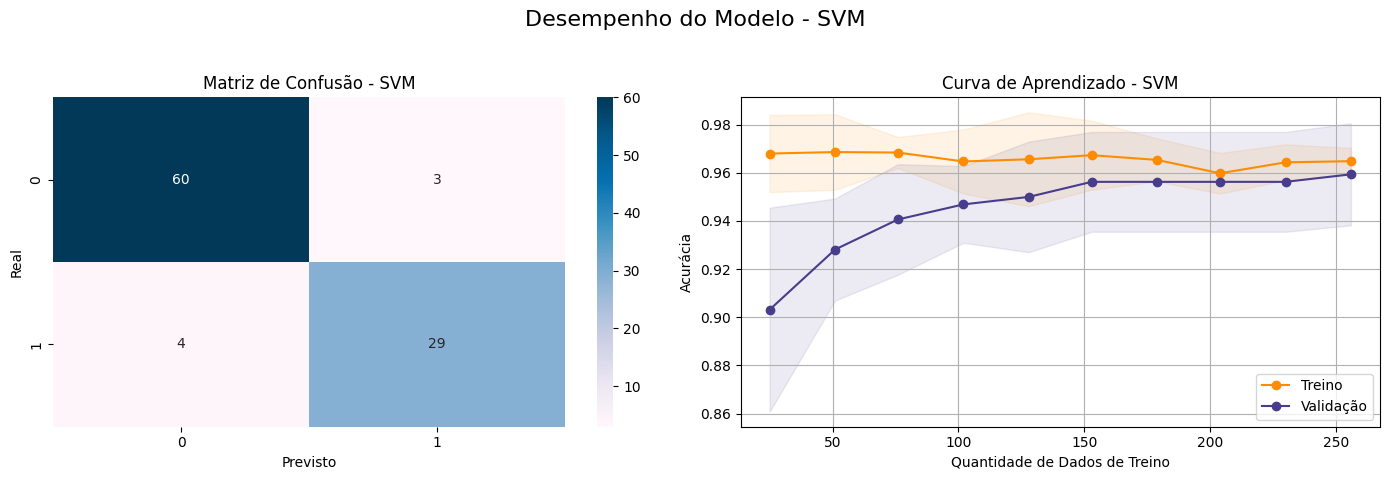

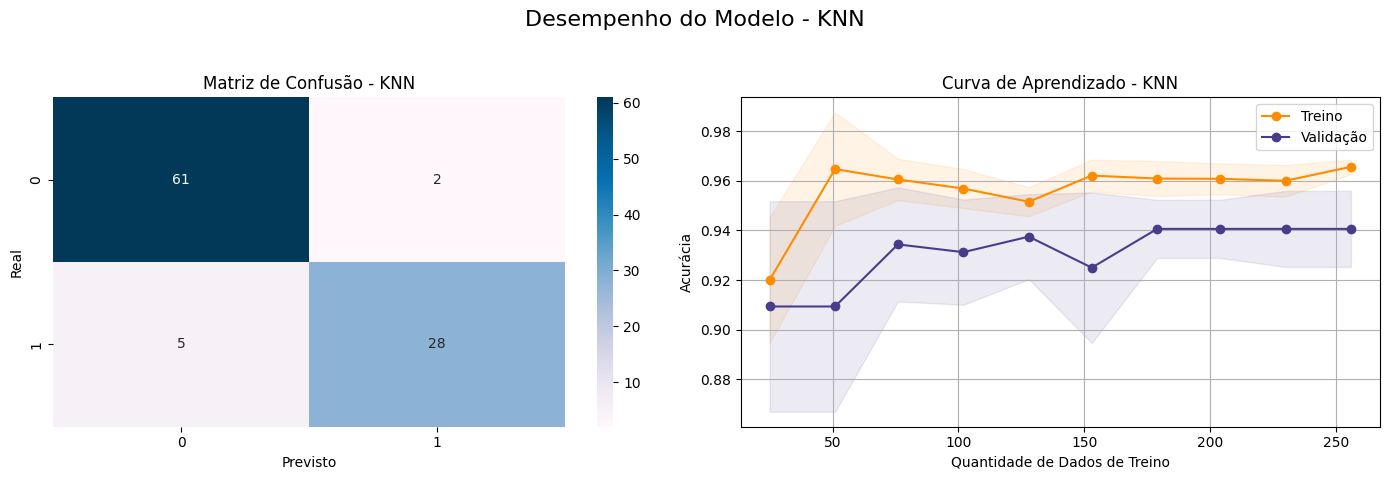

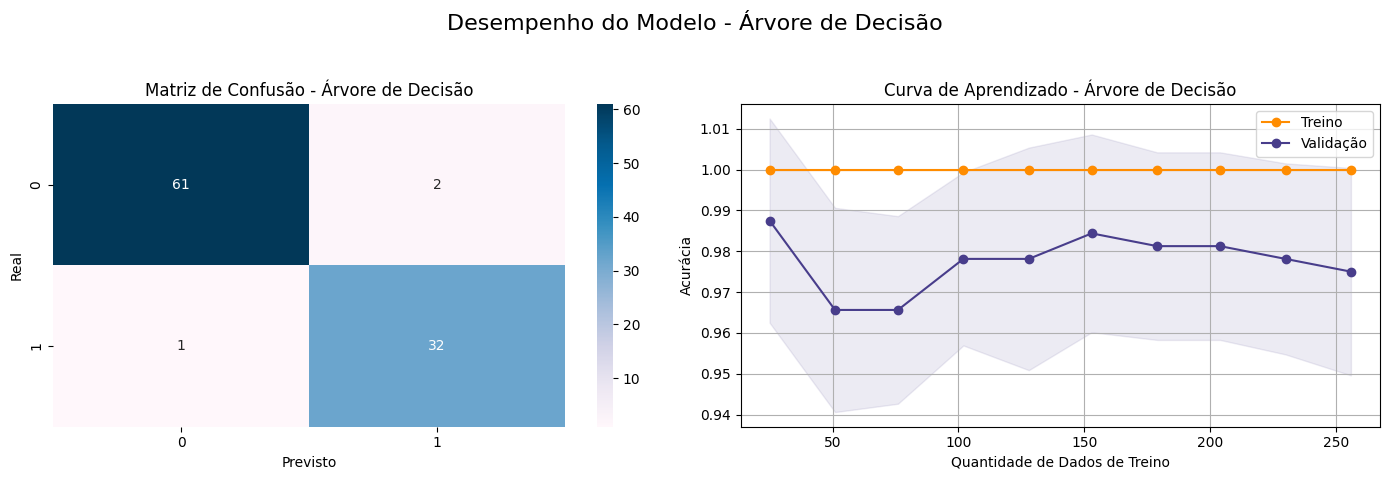

In [ ]:
 # Separação com estratificação e embaralhamento
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, shuffle=True, random_state=42
)

# Função para curva de aprendizado
def plot_learning_curve_ax(model, X, y, ax, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10), shuffle=True, random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, 'o-', label="Treino", color="#FF8C00")
    ax.plot(train_sizes, val_mean, 'o-', label="Validação", color="#483D8B")
    ax.fill_between(train_sizes, train_mean - train_scores.std(axis=1),
                    train_mean + train_scores.std(axis=1), alpha=0.1, color="#FF8C00")
    ax.fill_between(train_sizes, val_mean - val_scores.std(axis=1),
                    val_mean + val_scores.std(axis=1), alpha=0.1, color="#483D8B")
    ax.set_title(title)
    ax.set_xlabel("Quantidade de Dados de Treino")
    ax.set_ylabel("Acurácia")
    ax.legend(loc="best")
    ax.grid(True)

# Criar gráficos lado a lado e salvar
for nome, modelo in modelos.items():
    # Treinar e prever para matriz de confusão
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Criar figura com subplots lado a lado
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de confusão
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', ax=ax1)
    ax1.set_title(f"Matriz de Confusão - {nome}")
    ax1.set_xlabel("Previsto")
    ax1.set_ylabel("Real")

    # Curva de aprendizado
    plot_learning_curve_ax(modelo, X, y, ax2, f"Curva de Aprendizado - {nome}")

    # Ajustar layout e salvar
    plt.suptitle(f"Desempenho do Modelo - {nome}", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"desempenho_{nome.lower().replace(' ', '_')}.png", dpi=300)
    plt.show()


In [ ]:

'''
# Separar para gerar as matrizes de confusão (apenas para visualização)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42)

#MATRIZES DE CONFUSÃO
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (nome, modelo) in zip(axes, modelos.items()):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuBu', ax=ax)
    ax.set_title(f"Matriz de Confusão - {nome}")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
plt.suptitle("Como cada modelo classifica os dados?", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#CURVAS DE APRENDIZADO
def plot_learning_curves(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1, shuffle=True, random_state=42
    )

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', label="Treino", color="#FF8C00")
    plt.plot(train_sizes, val_mean, 'o-', label="Validação", color="#483D8B")
    plt.fill_between(train_sizes, train_mean - train_scores.std(axis=1),
                     train_mean + train_scores.std(axis=1), alpha=0.1, color="#FF8C00")
    plt.fill_between(train_sizes, val_mean - val_scores.std(axis=1),
                     val_mean + val_scores.std(axis=1), alpha=0.1, color="#483D8B")
    plt.title(title)
    plt.xlabel("Quantidade de Dados de Treino")
    plt.ylabel("Acurácia")
    plt.legend(loc="best")
    plt.grid(True)

# Gerar gráfico para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, (nome, modelo) in zip(axes, modelos.items()):
    plt.sca(ax)
    plot_learning_curves(modelo, X, y, f"Curva de Aprendizado - {nome}")
plt.suptitle("Como o desempenho evolui com mais dados?", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
'''



'\n# Separar para gerar as matrizes de confusão (apenas para visualização)\nX_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.3, random_state=42)\n\n#MATRIZES DE CONFUSÃO\nfig, axes = plt.subplots(1, 3, figsize=(18, 5))\nfor ax, (nome, modelo) in zip(axes, modelos.items()):\n    modelo.fit(X_train, y_train)\n    y_pred = modelo.predict(X_test)\n    cm = confusion_matrix(y_test, y_pred)\n    sns.heatmap(cm, annot=True, fmt=\'d\', cmap=\'PuBu\', ax=ax)\n    ax.set_title(f"Matriz de Confusão - {nome}")\n    ax.set_xlabel("Previsto")\n    ax.set_ylabel("Real")\nplt.suptitle("Como cada modelo classifica os dados?", fontsize=16)\nplt.tight_layout(rect=[0, 0.03, 1, 0.95])\nplt.show()\n\n#CURVAS DE APRENDIZADO\ndef plot_learning_curves(model, X, y, title):\n    train_sizes, train_scores, val_scores = learning_curve(\n        model, X, y, cv=5, scoring=\'accuracy\', train_sizes=np.linspace(0.1, 1.0, 10),\n        n_jobs=-1, shuffle=True, random_state=42\n    )\n\n    train_me

In [ ]:
# Dicionário para armazenar os resultados por classe
relatorios_por_classe = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    relatorio = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Remove "accuracy", "macro avg" e "weighted avg", ficamos só com as classes
    relatorio_classes = {
        classe: {
            'Precisão': valores['precision'],
            'Revocação': valores['recall'],
            'F1-Score': valores['f1-score']
        }
        for classe, valores in relatorio.items()
        if classe not in ['accuracy', 'macro avg', 'weighted avg']
    }

    df_temp = pd.DataFrame(relatorio_classes).T
    df_temp['Modelo'] = nome
    relatorios_por_classe[nome] = df_temp

# Concatenar todos os modelos
df_relatorio = pd.concat(relatorios_por_classe.values())
df_relatorio.reset_index(inplace=True)
df_relatorio.rename(columns={'index': 'Classe'}, inplace=True)
df_relatorio = df_relatorio.reindex(columns=['Modelo','Classe', 'Precisão', 'Revocação', 'F1-Score'])

# Visualizar com estilo
display(
    df_relatorio.style
    .background_gradient(subset=["Precisão", "Revocação", "F1-Score"], cmap="Blues")
    .format(precision=3)
    .set_caption("📋 Desempenho por Classe e Modelo (Validação Cruzada)")
)


,Modelo,Classe,Precisão,Revocação,F1-Score
0,SVM,0,0.938,0.952,0.945
1,SVM,1,0.906,0.879,0.892
2,KNN,0,0.924,0.968,0.946
3,KNN,1,0.933,0.848,0.889
4,Árvore de Decisão,0,0.984,0.968,0.976
5,Árvore de Decisão,1,0.941,0.970,0.955
